In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving train (2).csv to train (2).csv


In [ ]:
df = pd.read_csv("train (2).csv")

In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Распределение признаков Survived, Pclass, Age, Sex, Parch

Text(0.5, 0, 'number of children/parents onboard')

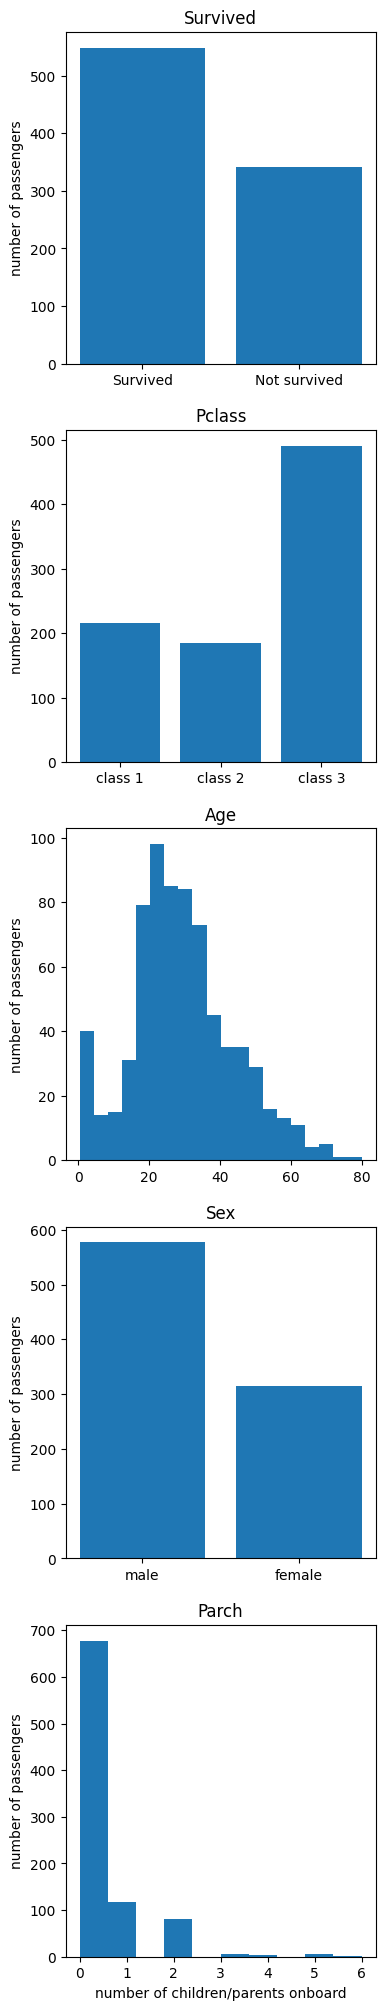

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(5, figsize=(4, 25))
axs[0].bar(
    x=['Survived','Not survived'],
    height=df['Survived'].value_counts()
)
axs[0].set_ylabel('number of passengers')
axs[0].set_title('Survived')

axs[1].bar(
    x=['class 1','class 2', 'class 3'],
    height=df['Pclass'].value_counts().sort_index()
)
axs[1].set_ylabel('number of passengers')
axs[1].set_title('Pclass')

axs[2].hist(df['Age'], bins=20)
axs[2].set_title('Age')
axs[2].set_ylabel('number of passengers')

axs[3].bar(
    x=['male','female'],
    height=[
        len(df[df['Sex'] == 'male']),
        len(df[df['Sex'] == 'female'])
        ]
)
axs[3].set_ylabel('number of passengers')
axs[3].set_title('Sex')

axs[4].hist(df['Parch'])
axs[4].set_title('Parch')
axs[4].set_ylabel('number of passengers')
axs[4].set_xlabel('number of children/parents onboard')


boxplot для Age

Text(0.5, 1.0, 'Age distribution on Titanic')

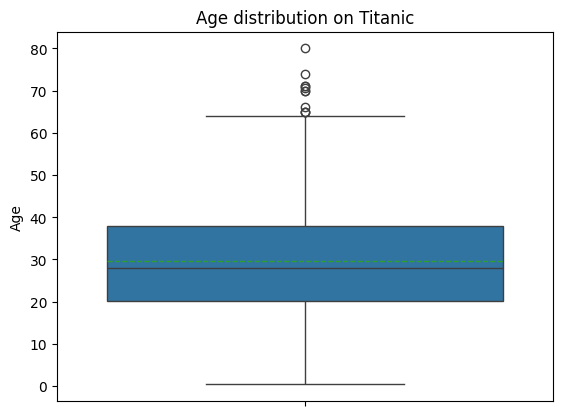

In [ ]:
import seaborn as sns
ax = sns.boxplot(df.Age, showmeans=True, meanline=True)
ax.set_title('Age distribution on Titanic')


по графику видно, что медианный возраст чуть меньше 30, а средний 30. Половина людей имеет возраст от 20 до 40 лет. Большинство людей имеет возраст менее 65. Всего лишь единицы имеют возраст 65 и более.

pie chart для переменных Survived, Pclass

Text(0.5, 1.0, 'Percentage of people survived')

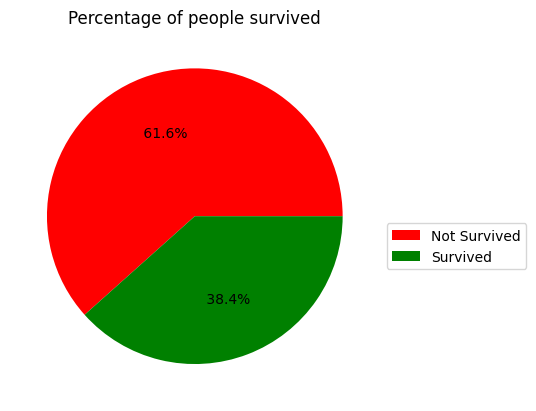

In [ ]:
survived_distribution = df.groupby(['Survived']).size().sort_index()

fig, ax = plt.subplots()
ax.pie(survived_distribution, autopct=' %1.1f%%', colors=['red', 'green'])
ax.legend(labels=['Not Survived', 'Survived'], bbox_to_anchor=(1, 0.5))
ax.set_title('Percentage of people survived')

Text(0.5, 1.0, 'Percentage of people in each class')

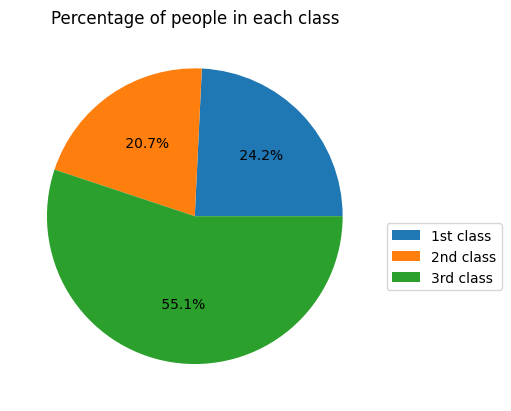

In [ ]:
class_distribution = df.groupby(['Pclass']).size().sort_index()

fig, ax = plt.subplots()
ax.pie(class_distribution, autopct=' %1.1f%%')
ax.legend(labels=['1st class', '2nd class', '3rd class'], bbox_to_anchor=(1, 0.5))
ax.set_title('Percentage of people in each class')

Pairplot для всех числовых переменных датасета

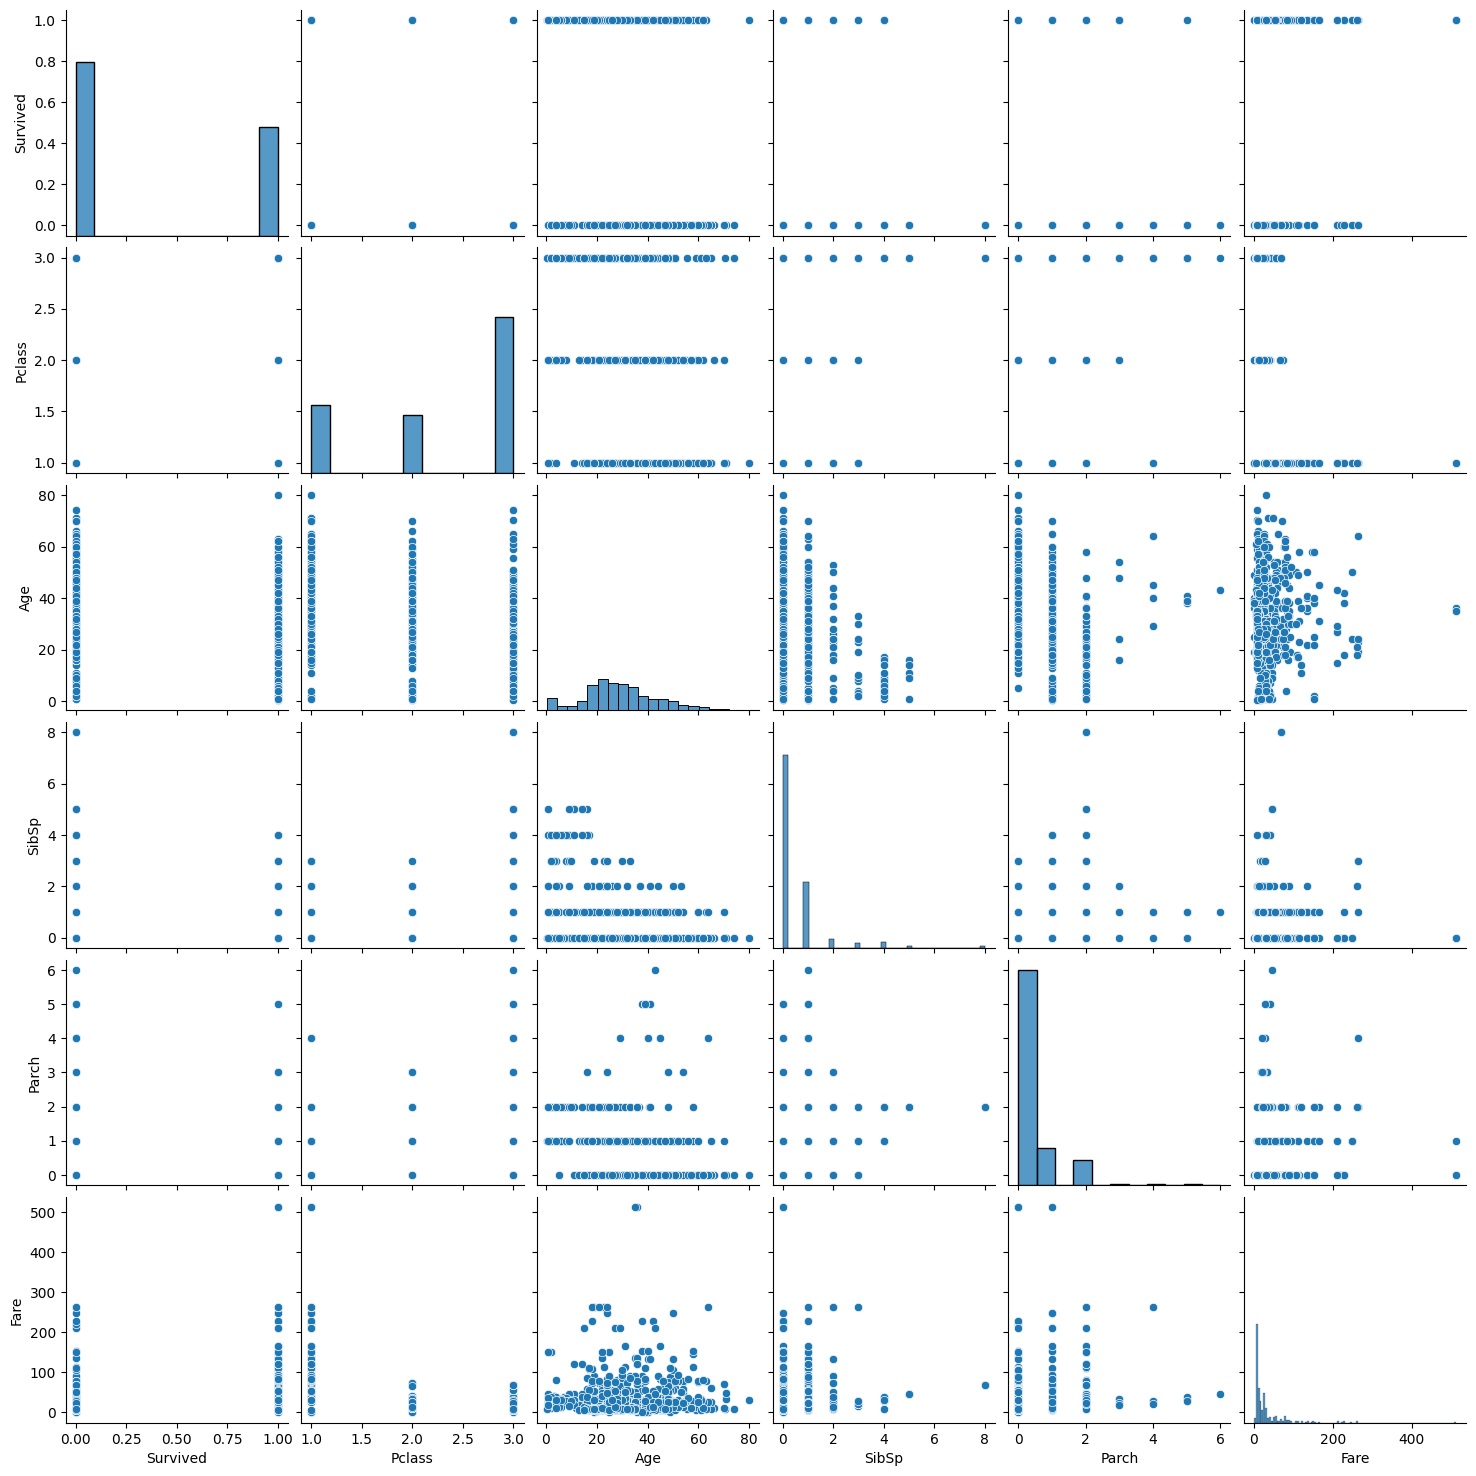

In [ ]:
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']])

Интерактивный sunburst plot

In [ ]:
import plotly.express as px

sunburst_df = df.groupby(['Pclass', 'Sex']).size().reset_index(name='count')
sunburst_df['Pclass'] = sunburst_df['Pclass'].map({
    1: '1st class',
    2: '2nd class',
    3: '3rd class'
})

px.sunburst(
    sunburst_df,
    path=['Pclass', 'Sex'],
    values='count',
    title="Number of people by sex in each class"
)